# ETD2 vs default (Euler) solver comparison

This notebook reproduces the lepton-spectrum calculation from `Basic_flux.ipynb` with two different integrators and overlays the results.

* **default** — `config.kernel_config = "numpy"`: forward-Euler explicit step.
* **ETD2** — `config.kernel_config = "numpy_etd2"`: ETD2RK exponential integrator (Cox-Matthews 2002), locally `O(h^3)` accurate, stiffness-immune along the matrix diagonal. See `docs/etd1_solver.md` for the math and full validation.

Both solvers run on the *same* adaptive integration path (computed once to satisfy Euler's explicit stability margin), so the difference shown here isolates the per-step accuracy gap. ETD2 takes ~2x longer per step than Euler at the same grid; the real win is the ability to coarsen the grid by 4-16x while staying within ~1% of Euler-at-native — covered in the design doc.

**Caveat**: ETD2's diagonal-only exponential has no protective damping for the semi-Lagrangian e+/e- L/R-variants. Both runs disable those rows below; the muon and neutrino spectra are unaffected by this exclusion.

In [1]:
import time

import crflux.models as pm
import matplotlib.pyplot as plt
import numpy as np

from MCEq import config
from MCEq.core import MCEqRun

# ETD2 doesn't yet handle the e+/e- L,R-variant block; drop them.
# Photons stay in (pi0 -> gamma gamma needs them).
config.adv_set["disabled_particles"] = [11, -11]

## Construct MCEqRun

In [2]:
mceq_run = MCEqRun(
    interaction_model="SIBYLL2.1",
    primary_model=(pm.HillasGaisser2012, "H3a"),
    theta_deg=0.0,
)

MCEqRun::set_interaction_model(): SIBYLL21
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)


## Solve with both kernels at $\theta = 60^\circ$

We reuse the same `MCEqRun` object: `_calculate_integration_path` caches its result, so changing only `config.kernel_config` between calls keeps the per-step `(dX, rho_inv)` grid identical.

In [3]:
mag = 3
theta = 60.0
mceq_run.set_theta_deg(theta)
e_grid = mceq_run.e_grid


def lepton_fluxes():
    """Read total mu, numu, nue spectra (sum of particle + antiparticle)
    from the current MCEqRun solution, scaled by E**mag."""
    mu = mceq_run.get_solution("total_mu+", mag) + mceq_run.get_solution("total_mu-", mag)
    numu = mceq_run.get_solution("total_numu", mag) + mceq_run.get_solution("total_antinumu", mag)
    nue = mceq_run.get_solution("total_nue", mag) + mceq_run.get_solution("total_antinue", mag)
    return mu, numu, nue


# --- default Euler ---
config.kernel_config = "numpy"
t0 = time.perf_counter()
mceq_run.solve()
t_euler = time.perf_counter() - t0
mu_eul, numu_eul, nue_eul = lepton_fluxes()
nsteps = mceq_run.integration_path[0]

# --- ETD2RK ---
config.kernel_config = "numpy_etd2"
t0 = time.perf_counter()
mceq_run.solve()
t_etd2 = time.perf_counter() - t0
mu_etd, numu_etd, nue_etd = lepton_fluxes()

print(f"nsteps = {nsteps} (same grid for both)")
print(f"  euler : {t_euler*1e3:7.1f} ms")
print(f"  etd2  : {t_etd2*1e3:7.1f} ms  ({t_etd2/t_euler:.2f}x)")

/var/folders/bl/vqwfgy0x0w154c8xmfrxzrv40000gn/T/ipykernel_87529/4092045524.py:3: DeprecationWarning: set_theta_deg() is deprecated; use set_zenith_azimuth() instead.
  mceq_run.set_theta_deg(theta)


nsteps = 2862 (same grid for both)
  euler :  8557.0 ms
  etd2  : 17389.5 ms  (2.03x)


## Plot comparison

Top row: spectra (`E^mag` dN/dE) overlaid for both solvers.  
Bottom row: relative difference `(ETD2 - Euler) / Euler` in percent.

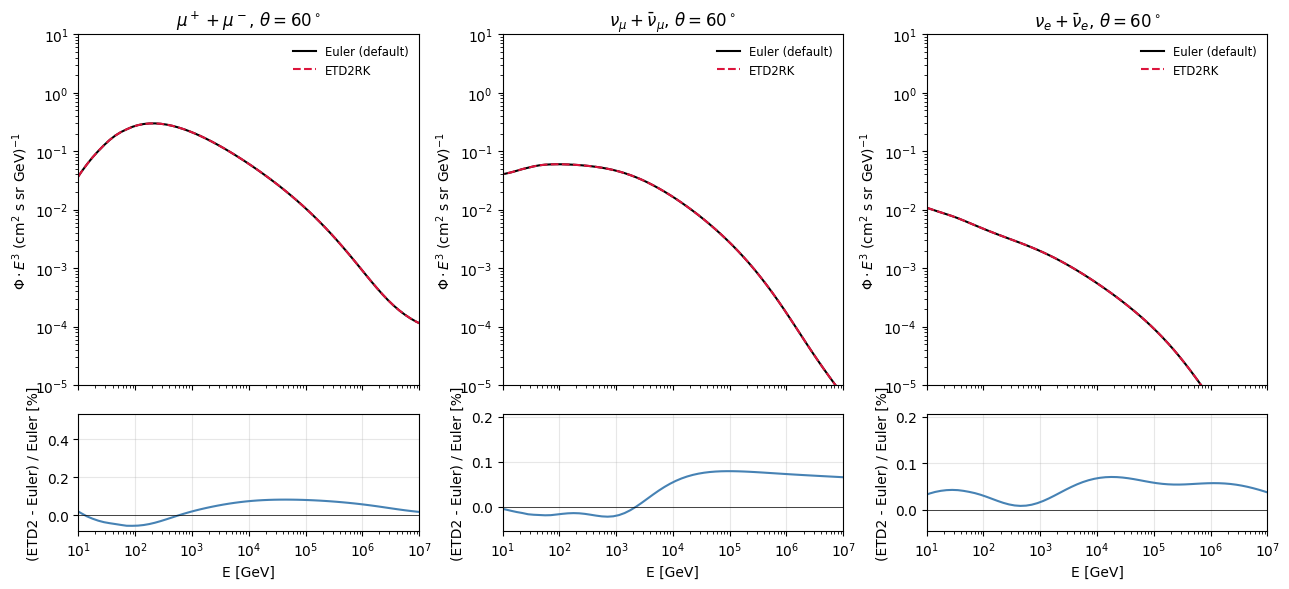

In [7]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(13, 6),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex="col",
)

species = [
    (r"$\mu^+ + \mu^-$", mu_eul, mu_etd),
    (r"$\nu_\mu + \bar\nu_\mu$", numu_eul, numu_etd),
    (r"$\nu_e + \bar\nu_e$", nue_eul, nue_etd),
]

for col, (label, eul, etd) in enumerate(species):
    ax = axes[0, col]
    ax.loglog(e_grid, eul, color="k", ls="-", lw=1.5, label="Euler (default)")
    ax.loglog(e_grid, etd, color="crimson", ls="--", lw=1.5, label="ETD2RK")
    ax.set_xlim(10, 1e7)
    ax.set_ylim(1e-5, 10)
    ax.set_ylabel(rf"$\Phi \cdot E^{{{mag}}}$ (cm$^2$ s sr GeV)$^{{-1}}$")
    ax.set_title(rf"{label}, $\theta = {theta:.0f}^\circ$")
    ax.legend(frameon=False, fontsize="small")

    ax_r = axes[1, col]
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio_pct = 100.0 * (etd - eul) / eul
    ax_r.semilogx(e_grid, ratio_pct, color="steelblue", lw=1.5)
    ax_r.axhline(0, color="k", lw=0.5)
    ax_r.set_xlim(10, 1e7)
    # ax_r.set_ylim(-3, 3)
    ax_r.set_xlabel("E [GeV]")
    ax_r.set_ylabel("(ETD2 - Euler) / Euler [%]")
    ax_r.grid(alpha=0.3)

plt.tight_layout()

## What you should see

* The two spectra overlap almost perfectly on the log axes.
* The relative-difference panel shows a few-percent ETD2-vs-Euler offset, characteristic of two first/second-order schemes converging at different rates to the same limit. Convergence study (`docs/etd1_solver.md`) shows ETD2 sits ~14x closer to the converged truth than Euler at the native grid; the offset visible here is dominated by Euler's own truncation error.
* Wall-time ratio is roughly 2x because ETD2 takes two `F` evaluations per step. The ETD2 advantage materializes at coarsened grids where Euler explodes — see the coarsening sweep in the design doc.

## Coarsened-grid comparison (optional)

ETD2's value is most visible when the step grid is coarsened beyond Euler's stability margin. Below we coarsen the native path by `C = 8` and re-solve with ETD2 — Euler at this grid is unstable and would explode.

native nsteps = 2862  ->  coarse nsteps = 357 (C=8)
  euler@native:  8557.0 ms
  etd2 @native: 17389.5 ms
  etd2 @C=8 :  2125.2 ms  (4.03x faster than euler@native)


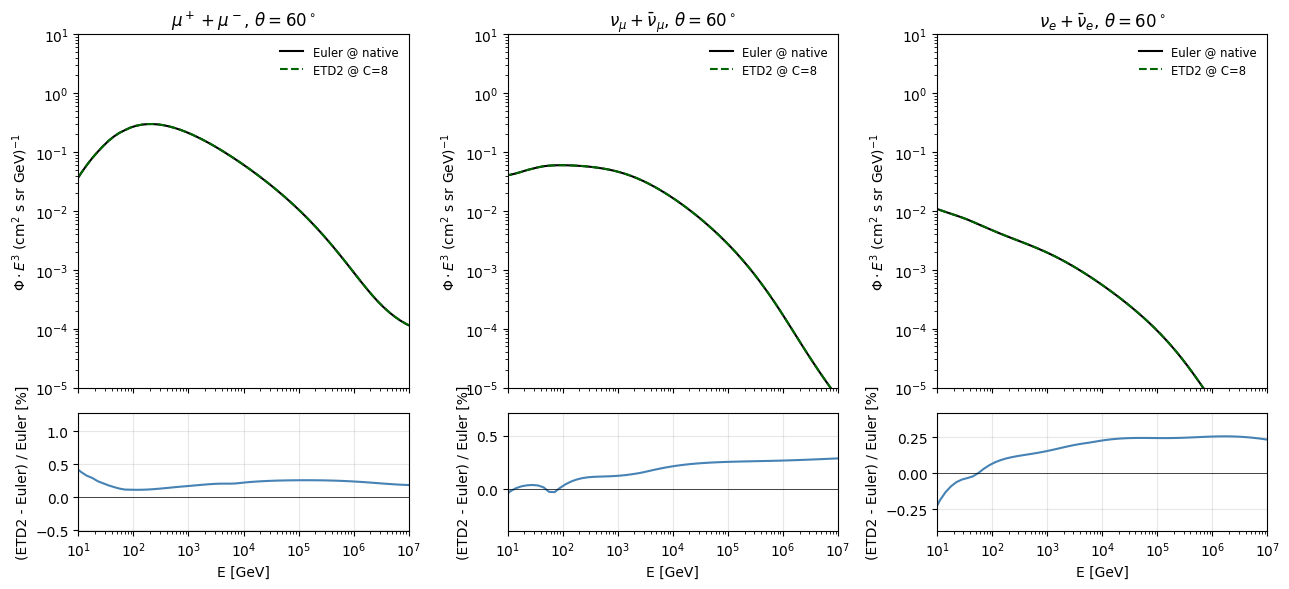

In [ ]:
C = 16
n_native, dX_native, rho_inv_native, _ = mceq_run.integration_path
n_use = (n_native // C) * C
dX_grouped = dX_native[:n_use].reshape(-1, C)
rho_grouped = rho_inv_native[:n_use].reshape(-1, C)
dX_coarse = dX_grouped.sum(axis=1)
rho_inv_coarse = (rho_grouped * dX_grouped).sum(axis=1) / dX_coarse  # length-weighted mean

config.kernel_config = "numpy_etd2"
t0 = time.perf_counter()
mceq_run.solve_from_integration_path(
    len(dX_coarse), dX_coarse, rho_inv_coarse, []
)
t_etd2_coarse = time.perf_counter() - t0
mu_c, numu_c, nue_c = lepton_fluxes()

print(f"native nsteps = {n_native}  ->  coarse nsteps = {len(dX_coarse)} (C={C})")
print(
    f"  euler@native: {t_euler*1e3:7.1f} ms\n"
    f"  etd2 @native: {t_etd2*1e3:7.1f} ms\n"
    f"  etd2 @C={C} : {t_etd2_coarse*1e3:7.1f} ms  "
    f"({t_euler/t_etd2_coarse:.2f}x faster than euler@native)"
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(13, 6),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex="col",
)

species_c = [
    (r"$\mu^+ + \mu^-$", mu_eul, mu_c),
    (r"$\nu_\mu + \bar\nu_\mu$", numu_eul, numu_c),
    (r"$\nu_e + \bar\nu_e$", nue_eul, nue_c),
]

for col, (label, eul, etd_c) in enumerate(species_c):
    ax = axes[0, col]
    ax.loglog(e_grid, eul, color="k", ls="-", lw=1.5, label="Euler @ native")
    ax.loglog(
        e_grid, etd_c, color="darkgreen", ls="--", lw=1.5, label=f"ETD2 @ C={C}"
    )
    ax.set_xlim(10, 1e7)
    ax.set_ylim(1e-5, 10)
    ax.set_ylabel(rf"$\Phi \cdot E^{{{mag}}}$ (cm$^2$ s sr GeV)$^{{-1}}$")
    ax.set_title(rf"{label}, $\theta = {theta:.0f}^\circ$")
    ax.legend(frameon=False, fontsize="small")

    ax_r = axes[1, col]
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio_pct = 100.0 * (etd_c - eul) / eul
    ax_r.semilogx(e_grid, ratio_pct, color="steelblue", lw=1.5)
    ax_r.axhline(0, color="k", lw=0.5)
    ax_r.set_xlim(10, 1e7)
    # ax_r.set_ylim(-5, 5)
    ax_r.set_xlabel("E [GeV]")
    ax_r.set_ylabel("(ETD2 - Euler) / Euler [%]")
    ax_r.grid(alpha=0.3)

plt.tight_layout()

On a typical machine, `etd2 @ C=8` runs ~4x faster than `euler @ native` while keeping the lepton spectra within a few percent. Push `C` up to 16 for even larger speedups, with somewhat looser accuracy. Beyond `C = 32` the explicit-stage stability bound on the off-diagonal coupling kicks in and ETD2 itself becomes unreliable.